# Introduction

This code generates the figures for the paper "Interannual controls of the phytoplankton assemblages in Baffin Bay".

## Directory structure

binder, where is the .yml file for the conda virtual environment.

data, where are the observed winter nutrients from the Qikiqtarjuaq ice camps 2015 and 2016, the prescribed winter nutrients for the sensitivity experiments, the outputs of the model MITgcm and the observed winter nutrients for the 11 expeditions mentioned in Ardyna et al. (2020) in *Elem. Sci. Anth.*.

figures_supp, where are the figures for the supporting information.

## Environment

This notebook was run in a conda virtual environment. The following commands will automatically create the environment and launch the Jupyter notebook:

```
cd <my_path>/assemblages
conda env create -f binder/environment_assemblages.yml
conda activate assemblages
jupyter notebook
```

Once the environment assemblages is created, the Jupyter notebook can be launched simply with:

```
cd <my_path>/assemblages
conda activate assemblages
jupyter notebook
```

# Code

## Load libraries

In [1]:
%matplotlib inline

import cycler
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import netcdf_tools
import numpy as np
import os
import pandas as pd
import plankpy
import re
import read_mitgcm

## Parameters for the figures

In [2]:
# dpi='figure' # default dpi
dpi=600
# ext='png'
ext='jpeg'

## Date of the simulations

The date when the the simulations were ran in the format yyyymmdd will be used to construct the names of the output files.

In [3]:
indir_outputs='data/DataS3_outputs_short'

In [4]:
pattern=\
'^groups\.run_(?P<yyyymmdd>\d{8})\w*_sims_par_nomixogmax\.csv$'
regex=re.compile(pattern)
files=os.listdir(indir_outputs)
found=False
ifile=0
while(ifile<len(files) and not found):
    fname_example=files[ifile]
    match=regex.match(fname_example)
    if match!=None:
        found=True
        yyyymmdd=match.group('yyyymmdd')
    ifile=ifile+1
cwd=os.getcwd()
assert found, \
'current working directory %r contains no file with a name corresponding to %r' \
% (cwd,pattern)

In [5]:
fname_example

'groups.run_20240912_0000_EXP2_3no3_00_si_00_122_sims_par_nomixogmax.csv'

In [6]:
yyyymmdd

'20240912'

## Grid

In [7]:
gridfile\
='data/DataS4_outputs_long/run_20240930_0000_EXP2_3si_standard_no3_standard_122_sims/grid.t001.nc'

drF is the r cell face separation, meaning the thickness of each depth layer (in m).

It corresponds to delR on https://mitgcm.readthedocs.io/en/latest/getting_started/getting_started.html#grid

In [8]:
drF=netcdf_tools.read_netcdf(gridfile,'drF')

RC is the r coordiante of cell center (in m).
We switch sign to have positive depths.

In [9]:
RC=-netcdf_tools.read_netcdf(gridfile,'RC')

RF is the r coordinate of cell interface (in m). We switch sign to have positive depths.

In [10]:
RF=-netcdf_tools.read_netcdf(gridfile,'RF')

In [11]:
RF_above151=RF[RF<151]

## Time duration

Each year had 365 days in the simulation and there was a spinup of 10 years.

In [12]:
nbyears=10
last_year=np.arange(365*(nbyears-1)+0,365*(nbyears-1)+365)
array1d_iT1y_iT=last_year

For the plots or for the mesh data of heatmaps 
(see https://matplotlib.org/stable/gallery/images_contours_and_fields/pcolormesh_grids.html#sphx-glr-gallery-images-contours-and-fields-pcolormesh-grids-py).

In [13]:
first_year=np.arange(0,365)
first_year_from_may1=np.arange(121,365)

For the meshgrid of heatmaps.

In [14]:
first_year366_from_may1=np.arange(121,366)

## Reference nitrate and silicate

In [15]:
infile_no3_standard\
='data/DataS1_winter_nutrients_in_situ_qik/1D_BB_NO3_GE_spring.delZ1016mm.32bits.bin'
infile_si_standard\
='data/DataS1_winter_nutrients_in_situ_qik/1D_BB_Si_GE_spring.delZ1016mm.32bits.bin'

In [16]:
array1d_idepth_no3_standard=np.fromfile(infile_no3_standard,
                                        dtype='>f')
array1d_idepth_si_standard=np.fromfile(infile_si_standard,
                                       dtype='>f')

# Heatmaps for different winter nutrient concentrations without mixotrophy

Read reference nitrate at 100 m (in $\mathrm{ \mu mol\ L^{-1} }$).

In [17]:
x=100
xp=[RC[28],RC[29]] # Between 95.5528315 m and 101.2971055 m
assert np.all(np.diff(xp)>0), \
"xp is in decreasing order: %r %r" % (xp[0],xp[1])
fp=[array1d_idepth_no3_standard[28],array1d_idepth_no3_standard[29]]
no3_standard_100m=np.interp(x,xp,fp)

Read reference silicate at 100 m (in $\mathrm{ \mu mol\ L^{-1} }$).

In [18]:
array1d_idepth_si_standard=np.fromfile(infile_si_standard,dtype='>f')
x=100
xp=[RC[28],RC[29]] # Between 95.5528315 m and 101.2971055 m
assert np.all(np.diff(xp)>0), \
"xp is in decreasing order: %r %r" % (xp[0],xp[1])
fp=[array1d_idepth_si_standard[28],array1d_idepth_si_standard[29]]
si_standard_100m=np.interp(x,xp,fp)

In [19]:
reference_df=pd.DataFrame({
    'Cruise'  :['Reference'],
    'Nitrate' :[no3_standard_100m],
    'Silicate':[si_standard_100m]
})

In [20]:
reference_df

,Cruise,Nitrate,Silicate
0,Reference,7.401252,10.085529


In [21]:
indir_outputs_short='data/DataS3_outputs_short'

In [22]:
sims_no3   =[0,2,4,6,8,10,12,14,16,18,20]
sims_si    =[0,2,4,6,8,10,12,14,16,18,20]
nsims_no3  =len(sims_no3)
nsims_si   =len(sims_si)
imeshno3   =[-1]+[i+1 for i in sims_no3]
imeshsi    =[-1]+[i+1 for i in sims_si]
max_meshno3=max(imeshno3)
max_meshsi =max(imeshsi)

In [23]:
array2d_isi_ino3_diatoms_biomass =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_dino_biomass    =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_other_biomass   =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_pico_biomass    =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_total_biomass   =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_diatoms_perc    =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_dino_perc       =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_other_perc      =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_pico_perc       =np.zeros([nsims_si,nsims_no3])
my_formatter='{0:02}'
for isim_no3,sim_no3 in enumerate(sims_no3):
    for isim_si,sim_si in enumerate(sims_si):
        basename='groups.run_' \
        +yyyymmdd \
        +'_0000_EXP2_3no3_'\
        +my_formatter.format(sim_no3)\
        +'_si_'\
        +my_formatter.format(sim_si)\
        +'_122_sims_par_nomixogmax.csv'
        absname=os.path.join(indir_outputs_short,basename)
        groups_df=pd.read_csv(absname,dtype=np.float32)
        array2d_isi_ino3_diatoms_biomass[isim_si,isim_no3]\
        =groups_df['diatoms_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_dino_biomass[isim_si,isim_no3]\
        =groups_df['dino_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_other_biomass[isim_si,isim_no3]\
        =groups_df['other_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_pico_biomass[isim_si,isim_no3]\
        =groups_df['pico_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_total_biomass[isim_si,isim_no3]\
        =groups_df['total_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_diatoms_perc[isim_si,isim_no3]\
        =groups_df['diatoms_perc'].iloc[0]
        array2d_isi_ino3_dino_perc[isim_si,isim_no3]\
        =groups_df['dino_perc'].iloc[0]
        array2d_isi_ino3_other_perc[isim_si,isim_no3]\
        =groups_df['other_perc'].iloc[0]
        array2d_isi_ino3_pico_perc[isim_si,isim_no3]\
        =groups_df['pico_perc'].iloc[0]

Let $C_{dia,j}=
\text{(temporally and vertically integrated) biomass at day}
\ i\
\text{in} \mathrm{ \ g\ C\ m^{-2} }$

Let $C_{dia}=\frac{\sum_{i=1}^{365} C_{dia,j}}{365}
* \frac{1000\ mg\ C}{g \ C}$
in $\mathrm{ mg\ C\ m^{-2} }$

It is $C_{dia}$that is plotted.

First, find the simulations where the relative contribution of diatoms is > 50%.

Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=0\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [24]:
isi=0//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.0014930831966921687
2 6.67833427447917e-11
4 5.159085832151522e-12
6 3.131084801155648e-12
8 3.3100148056491863e-12
10 3.479059271574436e-12
12 3.5412337125173554e-12
14 3.5748708680782837e-12
16 3.5937539836355947e-12
18 3.6065430156217992e-12
20 3.6158929583168797e-12


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=2\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [25]:
isi=2//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11284203827381134
2 40.77667999267578
4 31.681842803955078
6 26.4518985748291
8 23.85788917541504
10 22.94526481628418
12 22.551591873168945
14 22.330947875976562
16 22.195222854614258
18 22.101898193359375
20 22.033615112304688


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=4\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [26]:
isi=4//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11284073442220688
2 40.95903396606445
4 49.32277297973633
6 41.609439849853516
8 36.528106689453125
10 34.89670944213867
12 34.3120231628418
14 34.01665496826172
16 33.84225082397461
18 33.72587966918945
20 33.6418342590332


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=6\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [27]:
isi=6//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11284073442220688
2 40.95903396606445
4 49.5738525390625
6 54.926025390625
8 48.47383499145508
10 45.11606216430664
12 44.10820388793945
14 43.661216735839844
16 43.41219711303711
18 43.253395080566406
20 43.14262771606445


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=8\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [28]:
isi=8//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11284073442220688
2 40.95903396606445
4 49.5738525390625
6 55.837520599365234
8 58.6918830871582
10 54.13606643676758
12 52.17757034301758
14 51.54688262939453
16 51.22652053833008
18 51.033592224121094
20 50.903648376464844


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=10\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [29]:
isi=10//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11284073442220688
2 40.95903396606445
4 49.5738525390625
6 55.837528228759766
8 60.63145446777344
10 61.90812683105469
12 59.00627517700195
14 58.04422378540039
16 57.679927825927734
18 57.47767639160156
20 57.3465576171875


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=12\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [30]:
isi=12//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11284073442220688
2 40.95903396606445
4 49.5738525390625
6 55.837528228759766
8 60.63161849975586
10 64.3420639038086
12 64.76781463623047
14 63.109947204589844
16 62.696189880371094
18 62.52699279785156
20 62.42342758178711


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=14\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [31]:
isi=14//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11284073442220688
2 40.95903396606445
4 49.5738525390625
6 55.837528228759766
8 60.63161849975586
10 64.34580993652344
12 66.63176727294922
14 67.04439544677734
16 66.3515396118164
18 66.09568786621094
20 66.03044891357422


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=16\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [32]:
isi=16//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11284073442220688
2 40.95903396606445
4 49.5738525390625
6 55.837528228759766
8 60.63161849975586
10 64.34580993652344
12 66.64358520507812
14 68.10961151123047
16 68.73844146728516
18 68.59185791015625
20 68.49639129638672


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=18\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [33]:
isi=18//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11284073442220688
2 40.95903396606445
4 49.5738525390625
6 55.837528228759766
8 60.63161849975586
10 64.34580993652344
12 66.64359283447266
14 68.12239837646484
16 69.15977478027344
18 69.71400451660156
20 69.89913940429688


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=20\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [34]:
isi=20//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11284073442220688
2 40.95903396606445
4 49.5738525390625
6 55.837528228759766
8 60.63161849975586
10 64.34580993652344
12 66.64359283447266
14 68.12254333496094
16 69.16673278808594
18 69.8555908203125
20 70.2939224243164


In [35]:
# the contour
data={'x':[ 5, 5, 7, 7,21], # nitrate
      'y':[21, 5, 5, 7, 7]} # silicate
df=pd.DataFrame(data)
df

,x,y
0,5,21
1,5,5
2,7,5
3,7,7
4,21,7


In [36]:
xoffset=0.01
marker='*'

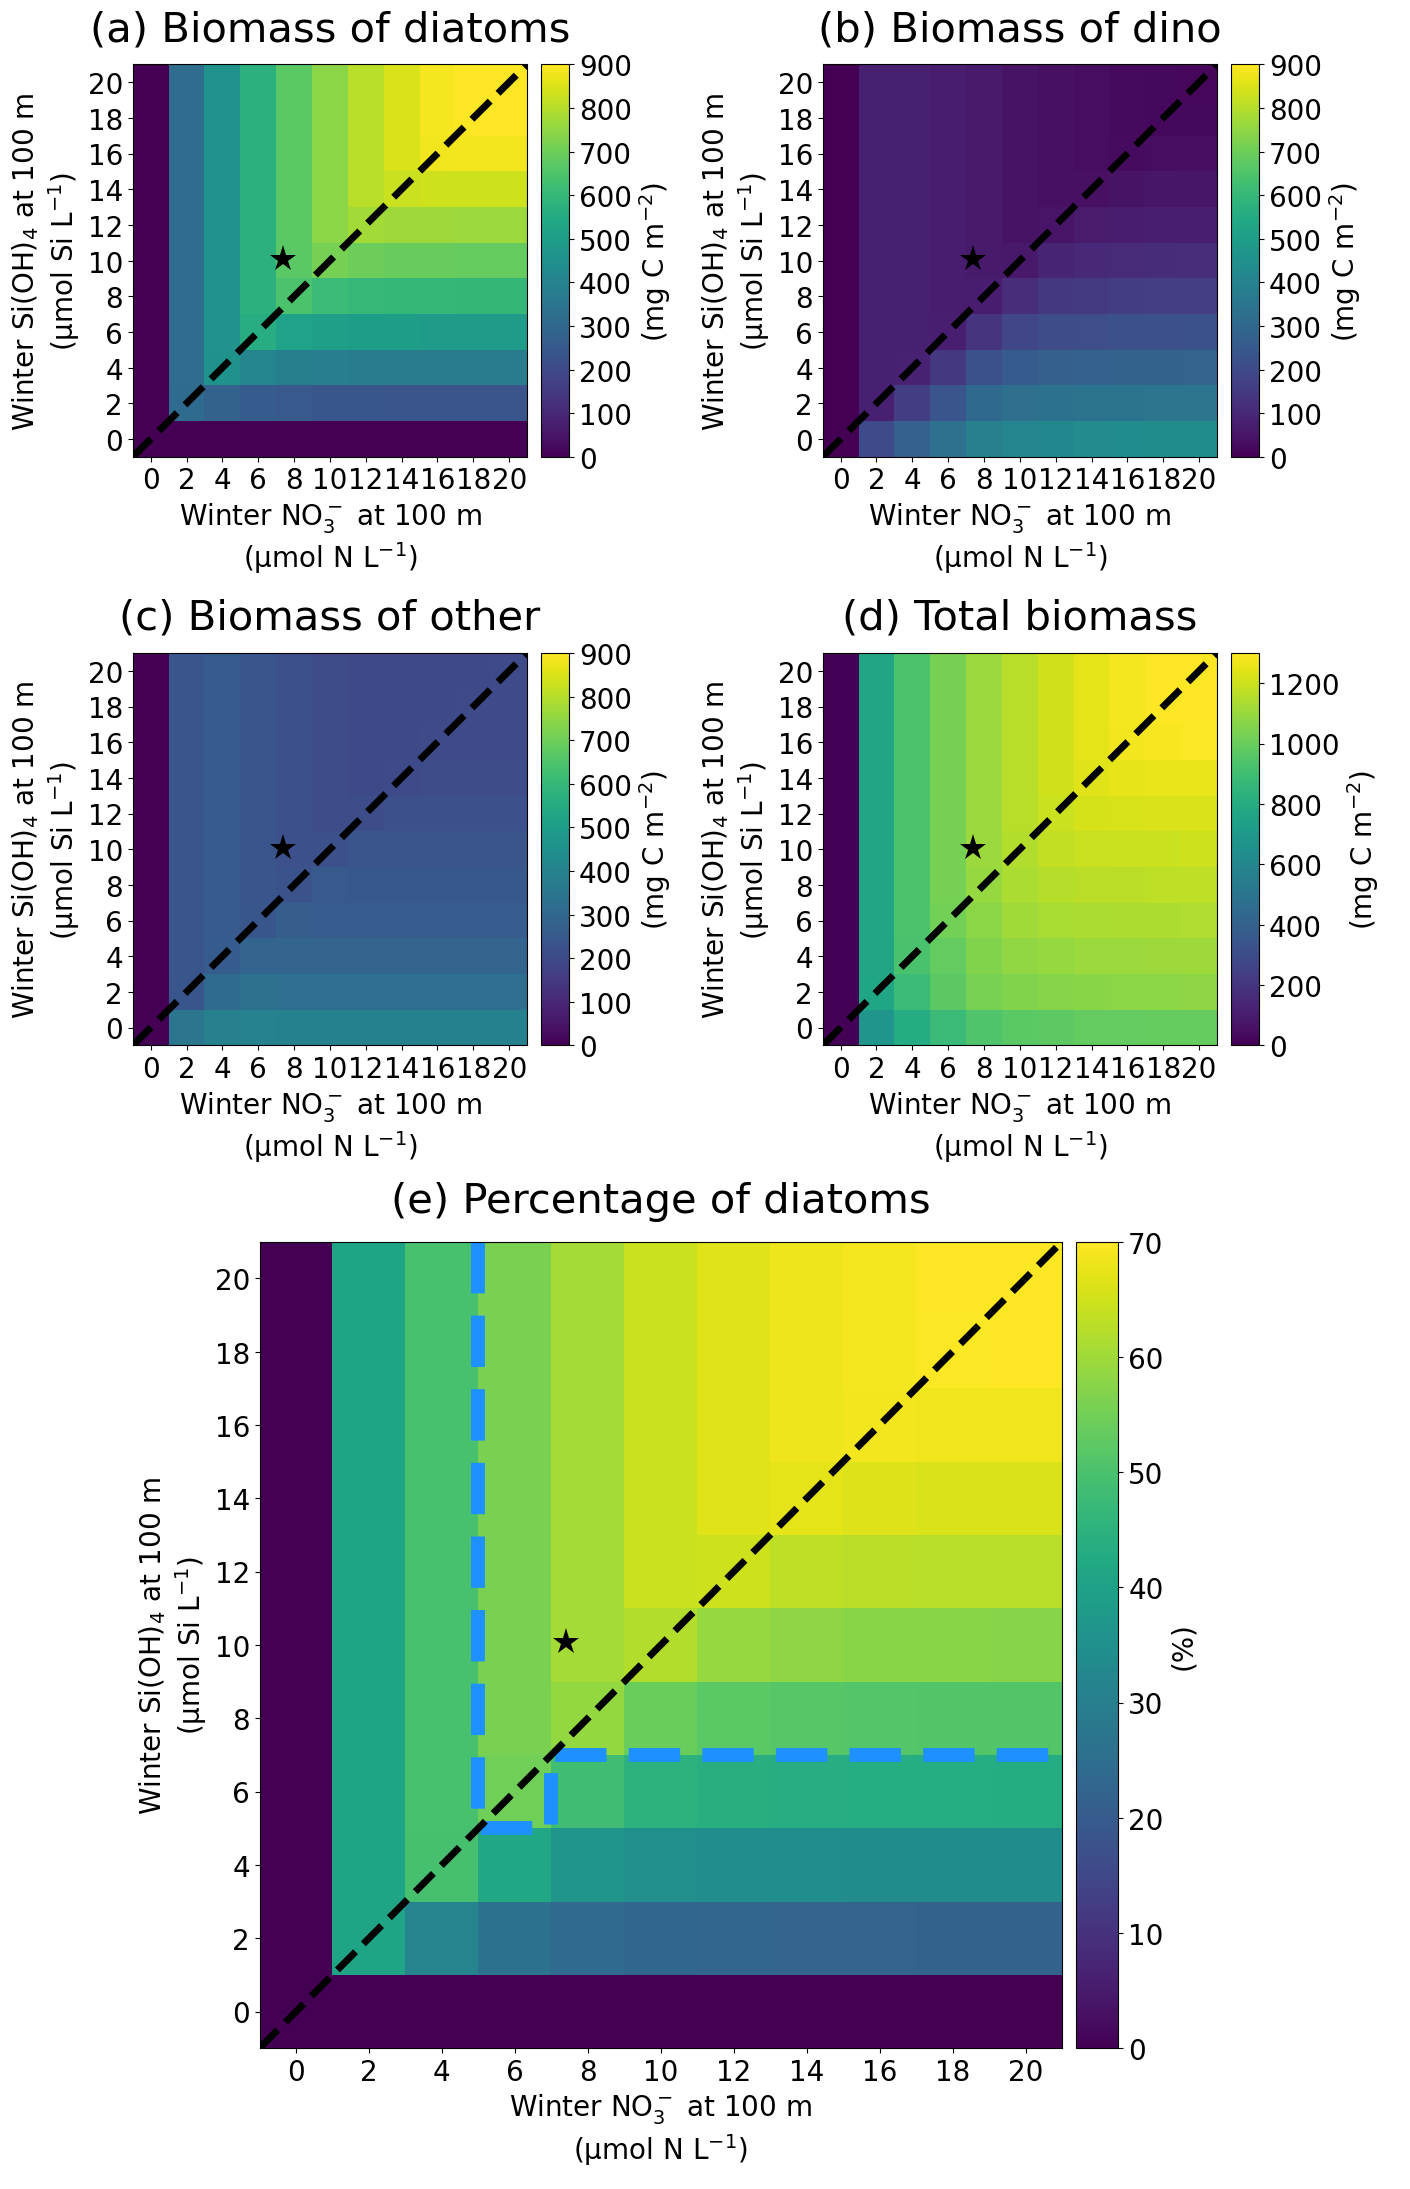

In [37]:
def make_plots(axs):
    
    # --- BIOMASS OF DIATOMS
    ax=axs[0,0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_diatoms_biomass/365*1000,
                    vmin=0,
                    vmax=900)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.39,0.79, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(a) Biomass of diatoms',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- BIOMASS OF DINOFLAGELLATES
    ax=axs[0,1]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_dino_biomass/365*1000,
                    vmin=0,
                    vmax=900)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.39,0.52, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(b) Biomass of dino',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- BIOMASS OF OTHER NANOPHYTOPLANKTON
    ax=axs[1,0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_other_biomass/365*1000,
                    vmin=0,
                    vmax=900)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.88,0.79, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(c) Biomass of other',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- TOTAL BIOMASS
    ax=axs[1,1]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_total_biomass/365*1000,
                    vmin=0,
                    vmax=1300)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.88,0.52, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(d) Total biomass',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- PERCENTAGE OF DIATOMS
    ax=axs[2,0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_diatoms_perc,
                    vmin=0,
                    vmax=70)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.77,0.06, 0.03,0.37])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('(%)')
    plt.text(0.50,1.05,'(e) Percentage of diatoms',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    
    # enclose region where diatoms > 50%
    h=ax.plot(np.array(df.x),np.array(df.y),
              color='dodgerblue',linestyle='--')
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- NOTHING
    ax=axs[2,1]
    ax.axis('off')
    
    # --- POSITION
    axs[0,0].set_position([0.10,0.79, 0.28,0.18])
    axs[0,1].set_position([0.59,0.79, 0.28,0.18])
    axs[1,0].set_position([0.10,0.52, 0.28,0.18])
    axs[1,1].set_position([0.59,0.52, 0.28,0.18])
    axs[2,0].set_position([0.19,0.06, 0.57,0.37])
    axs[2,1].set_position([0.99,0.00, 0.01,0.01])

with plt.style.context('mplstyles/groups_exp2_3.mplstyle'):
    # Plot
    fig,axs=plt.subplots(nrows=3,ncols=2,figsize=(14.08,21.80))
    make_plots(axs)

    # --- SAVE
    outfile='figures_supp/figureS1.'+ext
    plt.savefig(outfile,dpi=dpi)